# 6 筛选设计

> **图 6.1**：（左）钻孔函数的索博尔总指数。一阶指数以浅蓝色显示，总指数与一阶指数的差值以粉色显示。（右）主效应图

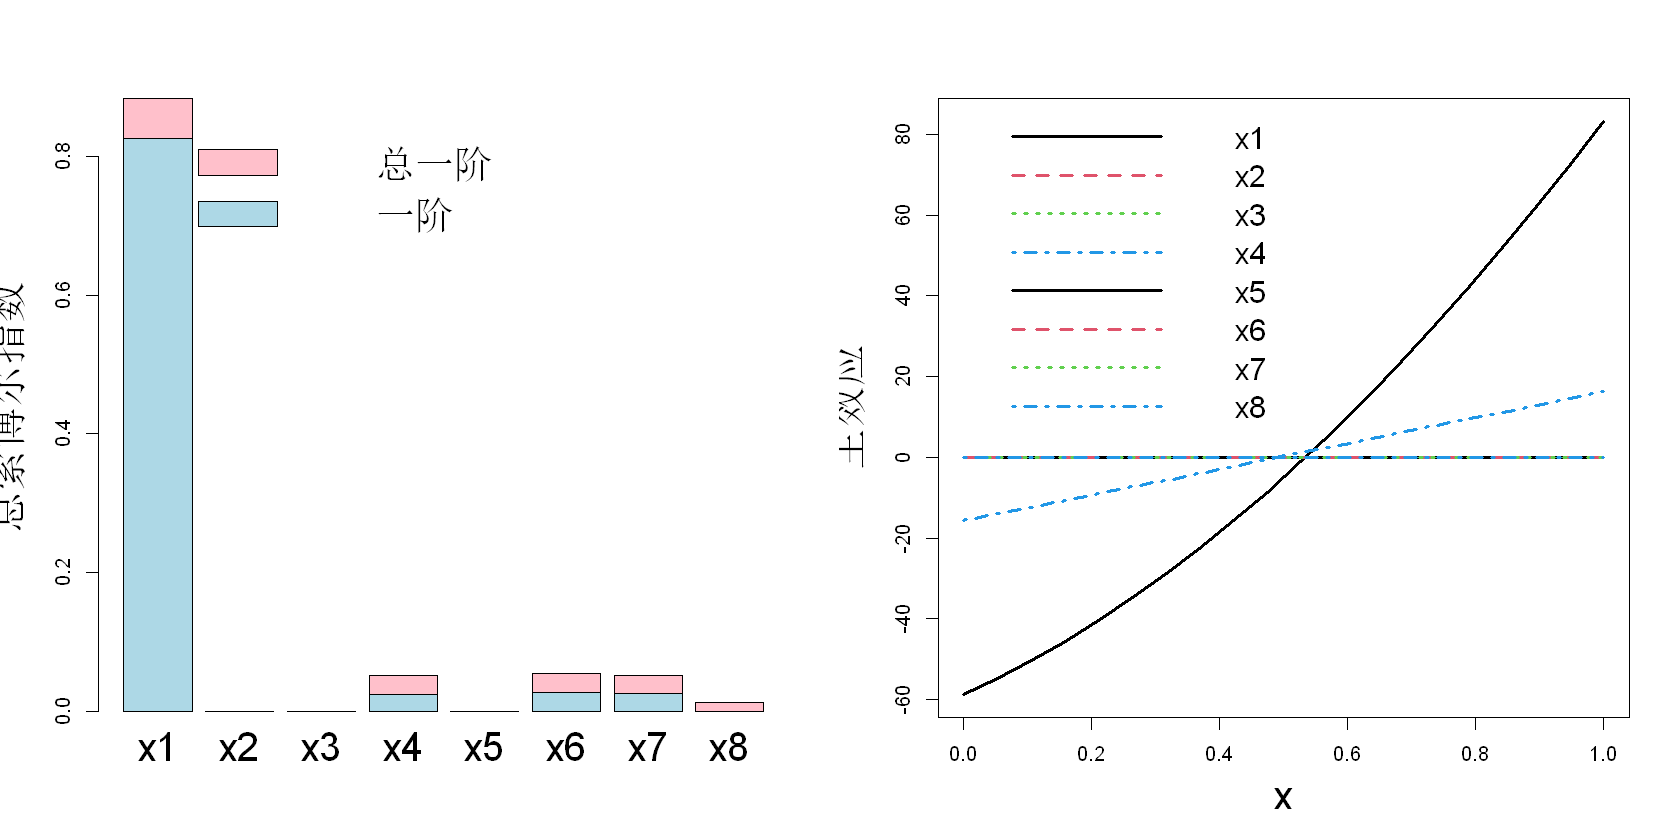

In [4]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/6.1-plot.RData")){
  f=function(x){
    lower=c(0.05,100,63070,990,63.1,700,1120,9855)
    upper=c(0.15,50000,115600,1110,116,820,1680,12045)
    x=lower+x*(upper-lower)
    val=2*pi*x[3]*(x[4]-x[6])/(log(x[2]/x[1])*(1+2*x[7]*x[3]/(log(x[2]/x[1])*x[1]^2*x[8])+x[3]/x[5]))
    return(val)
  }
  set.seed(1)
  p=8
  library(sensitivity)
  m=10000
  A=matrix(runif(m*p),nrow=m)
  B=matrix(runif(m*p),nrow=m)
  borehole=function(X) apply(X,1,f)
  a.sen=soboljansen(model=borehole,X1=data.frame(A),X2=data.frame(B))
  print(a.sen)
  sf=pmax(unlist(a.sen$S),0)
  st=pmax(unlist(a.sen$T),0)
  x=matrix(c(sf,st-sf),nrow=2,byrow=TRUE) # 2x8
  colnames(x)=paste("x",sep="",1:8)
  rownames(x)=c("first order","total-first order")
  library(SFDesign)
  library(rkriging)
  p=8
  n=10*p
  D=maxpro.optim(maxproLHD(n,p)$design)$design
  y=apply(D,1,f)
  a.fit=Fit.Kriging(D,y,kernel.parameters=list(type="Gaussian"))
  fhat=function(x,fit) Predict.Kriging(fit,matrix(x,ncol=p))$mean
  N=10*p
  D.eval=uniformLHD(N,p)$design
  f.eval=apply(D.eval,1,fhat,a.fit)
  f0=mean(f.eval)
  x.ev=seq(0,1,length=20) # 20x1
  val=x.ev
  main.effect=function(ind){
    D0=D.eval
    for(i in 1:20){
      D0[,ind]=rep(x.ev[i],N)
      val[i]=mean(apply(D0,1,fhat,a.fit))
    }
    return(val-f0)
  }
  M=matrix(0,nrow=20,ncol=p) # 20x8
  for(j in 1:4) M[,j]=main.effect(j)
  save(x,x.ev,M,file="data/6.1-plot.RData")
}

load("data/6.1-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
barplot(x,col=c("lightblue","pink"),names.arg=paste0("x",1:8),legend.text=c("一阶","总一阶"),cex.names=2,args.legend=list("cex"=2,"bty"="n"),ylab="总索博尔指数",cex.lab=2)
matplot(x.ev,M,type="l",lty=1:4,col=1:4,lwd=3,xlab="x",ylab="主效应",cex.lab=2)
legend("topleft",c("x1","x2","x3","x4","x5","x6","x7","x8"),bty="n",lty=1:4,col=1:4,lwd=3,cex=1.5)

> **图 6.2**：钻孔函数的基于导数的灵敏度指数，该估计过程在 $[0,1]^8$ 范围内采用四类样本重复执行 100 次

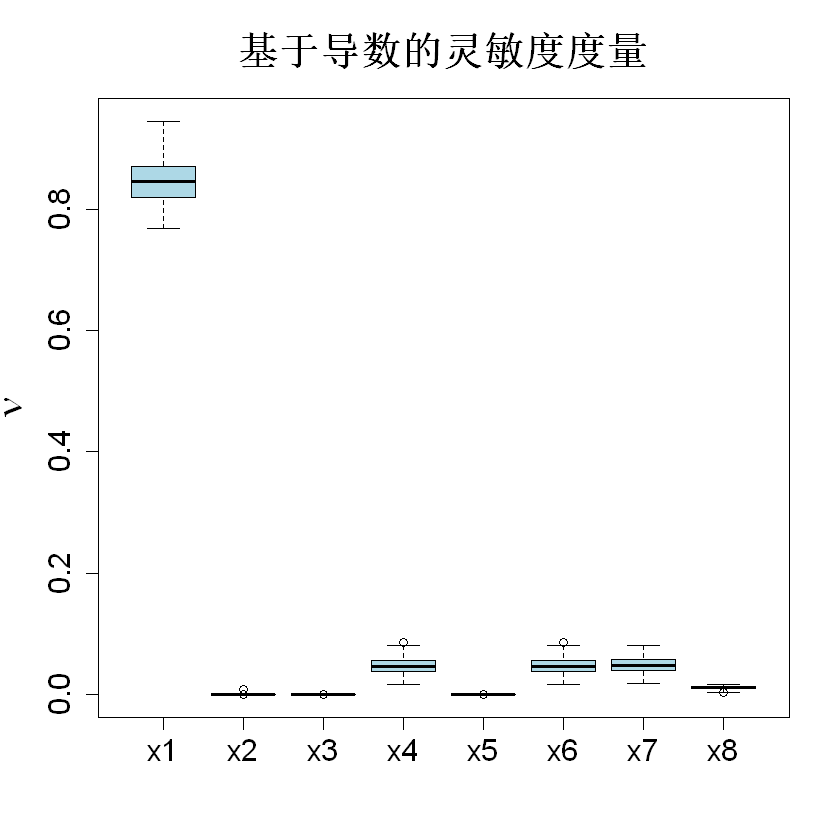

In [5]:
library(SFDesign)
library(sensitivity)
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/6.2-plot.RData")){
  set.seed(1)
  f=function(x) {
    lower<-c(0.05,100,63070,990,63.1,700,1120,9855)
    upper<-c(0.15,50000,115600,1110,116,820,1680,12045)
    x=lower+x*(upper-lower)
    val=2*pi*x[3]*(x[4]-x[6])/(log(x[2]/x[1])*(1+2*x[7]*x[3]/(log(x[2]/x[1])*x[1]^2*x[8])+x[3]/x[5]))
    return(val)
  }
  borehole=function(X) apply(X,1,f)
  p=8;m=4
  nu=matrix(0,nrow=100,ncol=p) # 100x8
  for(i in 1:100){
    X=matrix(runif(m*p),ncol=p)
    ad=delsa(model=borehole, X0=X,varprior=rep(1,p))
    nu[i,]=colMeans(ad$deriv^2)
    nu[i,]=nu[i,]/sum(nu[i,])
  }
  colnames(nu)=paste0("x",1:p)
  save(nu,file="data/6.2-plot.RData")
}

load("data/6.2-plot.RData")

options(repr.plot.width=7, repr.plot.height=7)
boxplot(nu,main="基于导数的灵敏度度量",cex.main=2,cex.axis=1.5,col="lightblue",ylab=expression(bar(nu)),cex.lab=2)

> **图 6.3**：（左）四维可加正弦函数图像；（右）四个因子对应的索博尔总指标与 $\nu_i$ 值

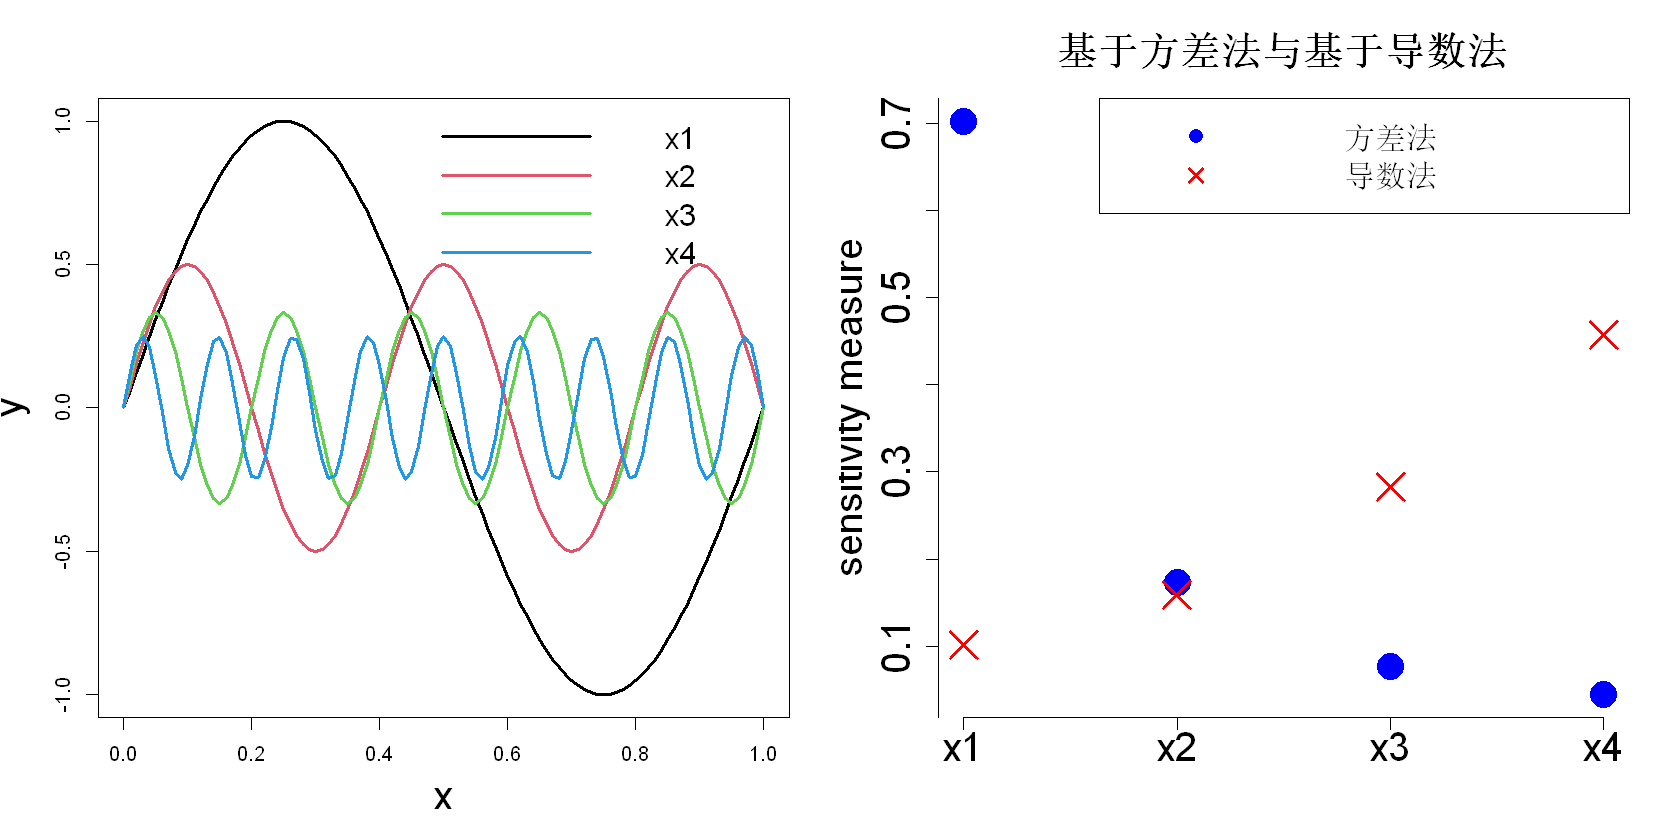

In [6]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/6.3-plot.RData")){
library(SFDesign)
library(sensitivity)
p=4
f=function(x){
  val=0
  for(k in 1:4) val=val+sin((k^2+1)*pi*x[k])/k
  return(val)
}
f1=function(X) apply(X,1,f)
X=uniformLHD(10*p,p)$design
a=delsa(model=f1,X0=X,varprior=rep(1,p))
nu=colMeans(a$deriv^2)
nu=nu/sum(nu) # 4x1
m=10000
A=matrix(runif(m*p),nrow=m)
B=matrix(runif(m*p),nrow=m)
a.sen=soboljansen(model=f1,X1=data.frame(A),X2=data.frame(B))
tot=a.sen$T$original # 4x1
save(nu,tot,file="data/6.3-plot.RData")
}

load("data/6.3-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
curve(sin(2*pi*x),from=0,to=1,lwd=3,ylab="y",cex.lab=2)
for(k in 2:4) curve(sin((k^2+1)*pi*x)/k,from=0,to=1,add=TRUE,col=k,lty=1,lwd=3)
legend("topright",legend=paste("x",sep="",1:4),col=1:4,lty=1,lwd=3,bty="n",cex=1.5)
plot(1:4,tot,col="blue",axes="F",cex=3,pch=16,xlab="",ylab="sensitivity measure",main="基于方差法与基于导数法",cex.main=2,cex.lab=2)
axis(1,at=1:4,labels=paste("x",sep="",1:4),cex.axis=2)
axis(2,seq(0,.8,.1),cex.axis=2)
points(1:4,nu,col="red",cex=3,pch=4,lwd=3)
legend("topright",legend=c("方差法","导数法"),col=c("blue","red"),pch=c(16,4),cex=1.5,lwd=3,lty=NA)

> **图 6.4**：莫里斯设计，左侧为严格单因素法，右侧为标准单因素法。箭头展示了单因素法的结构

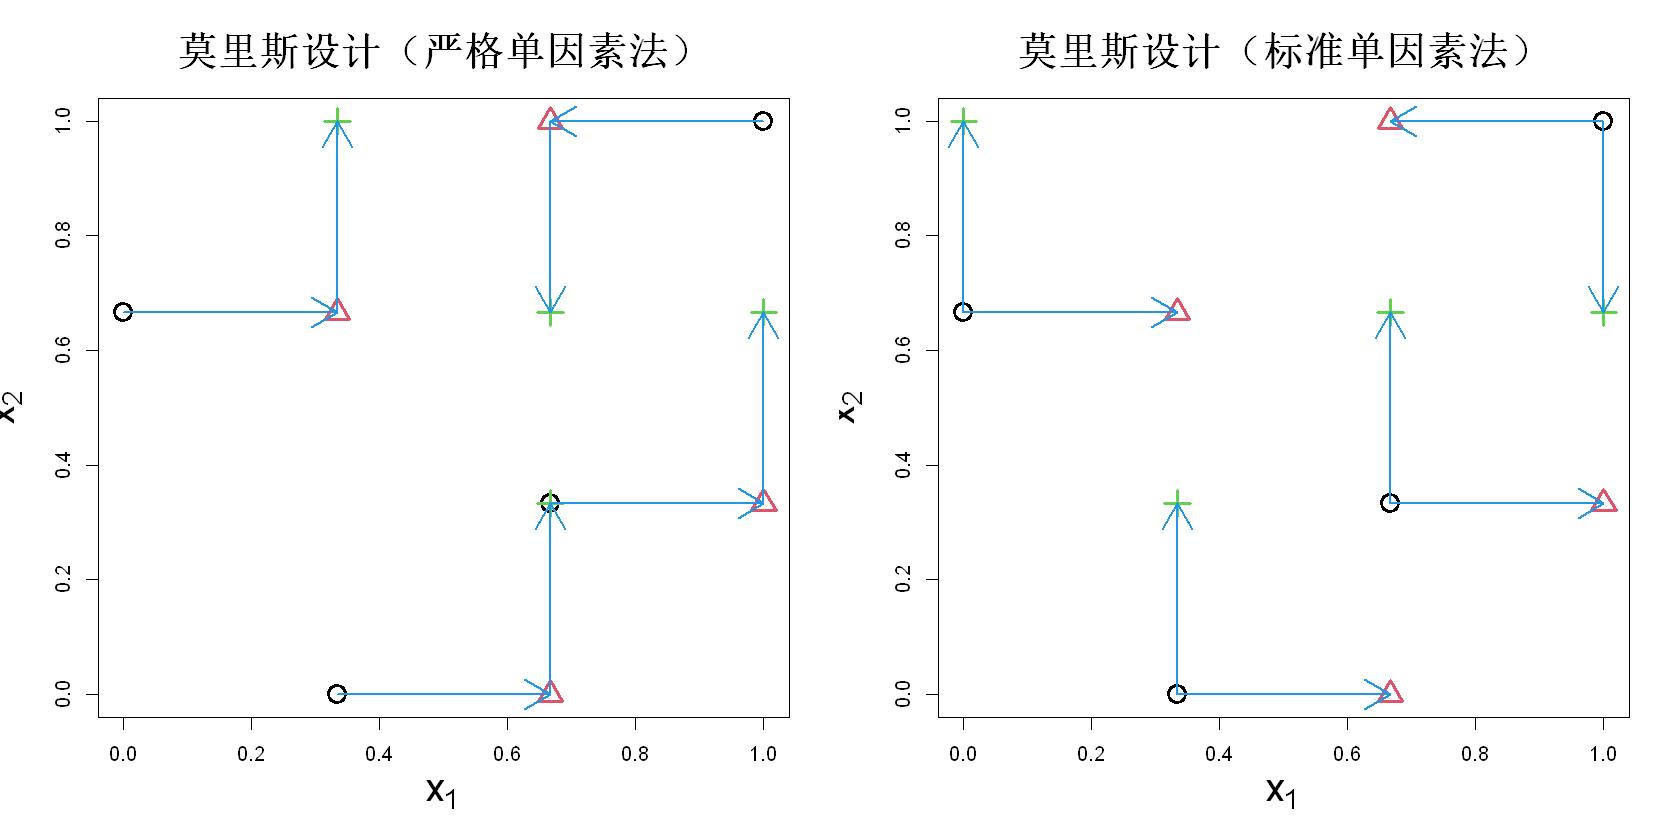

In [7]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/6.4-plot.RData")){
  set.seed(10)
  par(mfrow=c(1,2))
  x=((1:4)-1)/3
  A=cbind(x,sample(x)) # 4x2
  delta=1/3
  C11=C12=A
  for(i in 1:4){
    C11[i,1]=A[i,1]+delta
    if(C11[i,1]<0||C11[i,1]>1) C11[i,1]=A[i,1]-delta
    C12[i,1]=C11[i,1]
    C12[i,2]=C11[i,2]+delta
    if(C12[i,2]<0||C12[i,2]>1) C12[i,2]=C11[i,2]-delta
  }
  D=rbind(A,C11,C12)
  dim(unique(D))[1]
  
  C21=C22=A # 4x2
  for(i in 1:4){
    C21[i,1]=A[i,1]+delta
    if(C21[i,1]<0||C21[i,1]>1) C21[i,1]=A[i,1]-delta
    C22[i,2]=C21[i,2]+delta
    if(C22[i,2]<0||C22[i,2]>1) C22[i,2]=C21[i,2]-delta
  }
  D=rbind(A,C21,C22)
  dim(unique(D))[1]
  out=cbind(A, C11, C12, C21, C22)
  colnames(out)=c("A1","A2","C11.1","C11.2","C12.1","C12.2","C21.1","C21.2","C22.1","C22.2")
  save(A,C11,C12,C21,C22,file="data/6.4-plot.RData")
}

load("data/6.4-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
plot(A,xlab=expression(x[1]),ylab=expression(x[2]),xlim=c(0,1),ylim=c(0,1),lwd=3,cex=2,main="莫里斯设计（严格单因素法）",cex.main=2,cex.lab=2)
points(C11,col=2,pch=2,lwd=3,cex=2)
points(C12,col=3,pch=3,lwd=3,cex=2)
for(i in 1:4){
  arrows(A[i,1],A[i,2],C11[i,1],C11[i,2],col=4,lty=1,lwd=2)
  arrows(C11[i,1],C11[i,2],C12[i,1],C12[i,2],col=4,lty=1,lwd=2)
}

plot(A,xlab=expression(x[1]),ylab=expression(x[2]),xlim=c(0,1),ylim=c(0,1),lwd=3,cex=2,main="莫里斯设计（标准单因素法）",cex.main=2,cex.lab=2)
points(C21,col=2,pch=2,lwd=3,cex=2)
points(C22,col=3,pch=3,lwd=3,cex=2)
for(i in 1:4){
  arrows(A[i,1],A[i,2],C21[i,1],C21[i,2],col=4,lty=1,lwd=2)
  arrows(A[i,1],A[i,2],C22[i,1],C22[i,2],col=4,lty=1,lwd=2)
}

> **图 6.5**：（左）钻孔函数的莫里斯筛选设计结果。（右）100 次重复实验得到的 $\mu^*$ 箱线图

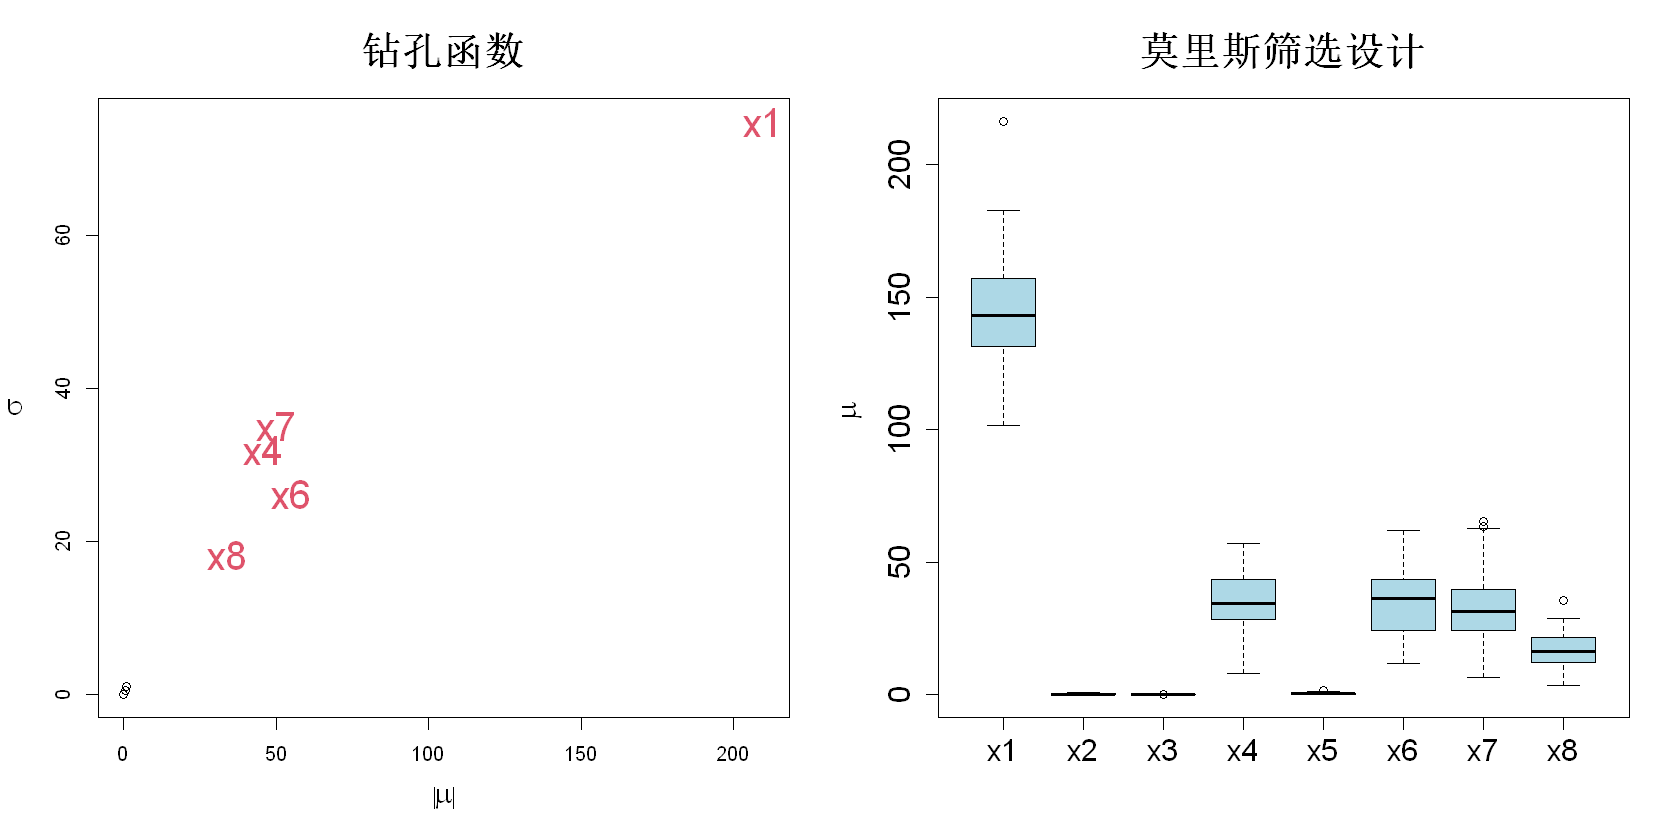

In [8]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/6.5-plot.RData")){
	library(sensitivity)
	f=function(x) {
    lower=c(0.05,100,63070,990,63.1,700,1120,9855)
    upper=c(0.15,50000,115600,1110,116,820,1680,12045)
    x=lower+x*(upper-lower)
    val=2*pi*x[3]*(x[4]-x[6])/(log(x[2]/x[1])*(1+2*x[7]*x[3]/(log(x[2]/x[1])*x[1]^2*x[8])+x[3]/x[5]))
    return(val)
  }
  borehole=function(X) apply(X,1,f)
  set.seed(1)
  a=morris(model=borehole,factors=8,r=4,design=list(type="oat",levels=4,grid.jump=2))
  mu=abs(apply(a$ee,2,function(x) mean(x)))
  sigma=apply(a$ee,2,sd)
  mustar=matrix(0,nrow=100,ncol=8)
  for(i in 1:100){
    am=morris(model=borehole,factors=8,r=4,design=list(type="oat",levels=4,grid.jump=2))
    mustar[i,]=apply(am$ee,2,function(x) mean(abs(x)))
  }
  lab=paste("x",sep="",1:8)
  colnames(mustar)=lab
  save(mu,sigma,mustar,file="data/6.5-plot.RData")
}

load("data/6.5-plot.RData")
sel=(mu>10)
lab=paste("x",sep="",1:8)

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
plot(mu,sigma,type="n",xlab=expression(abs(mu)),ylab=expression(sigma),cex.lab=1.5,main="钻孔函数",cex.main=2,cex=2)
text(mu[sel],sigma[sel],lab[sel],cex=2,col=2)
points(mu[!sel],sigma[!sel])
boxplot(mustar,main="莫里斯筛选设计",cex.main=2,cex.axis=1.5,col="lightblue",ylab=expression(mu^"*"),cex.lab=1.5)

> **图 6.6**：两种基于蒙特卡洛的索博尔设计实现。通过箭头展示单因素逐次变换（OFAT）结构

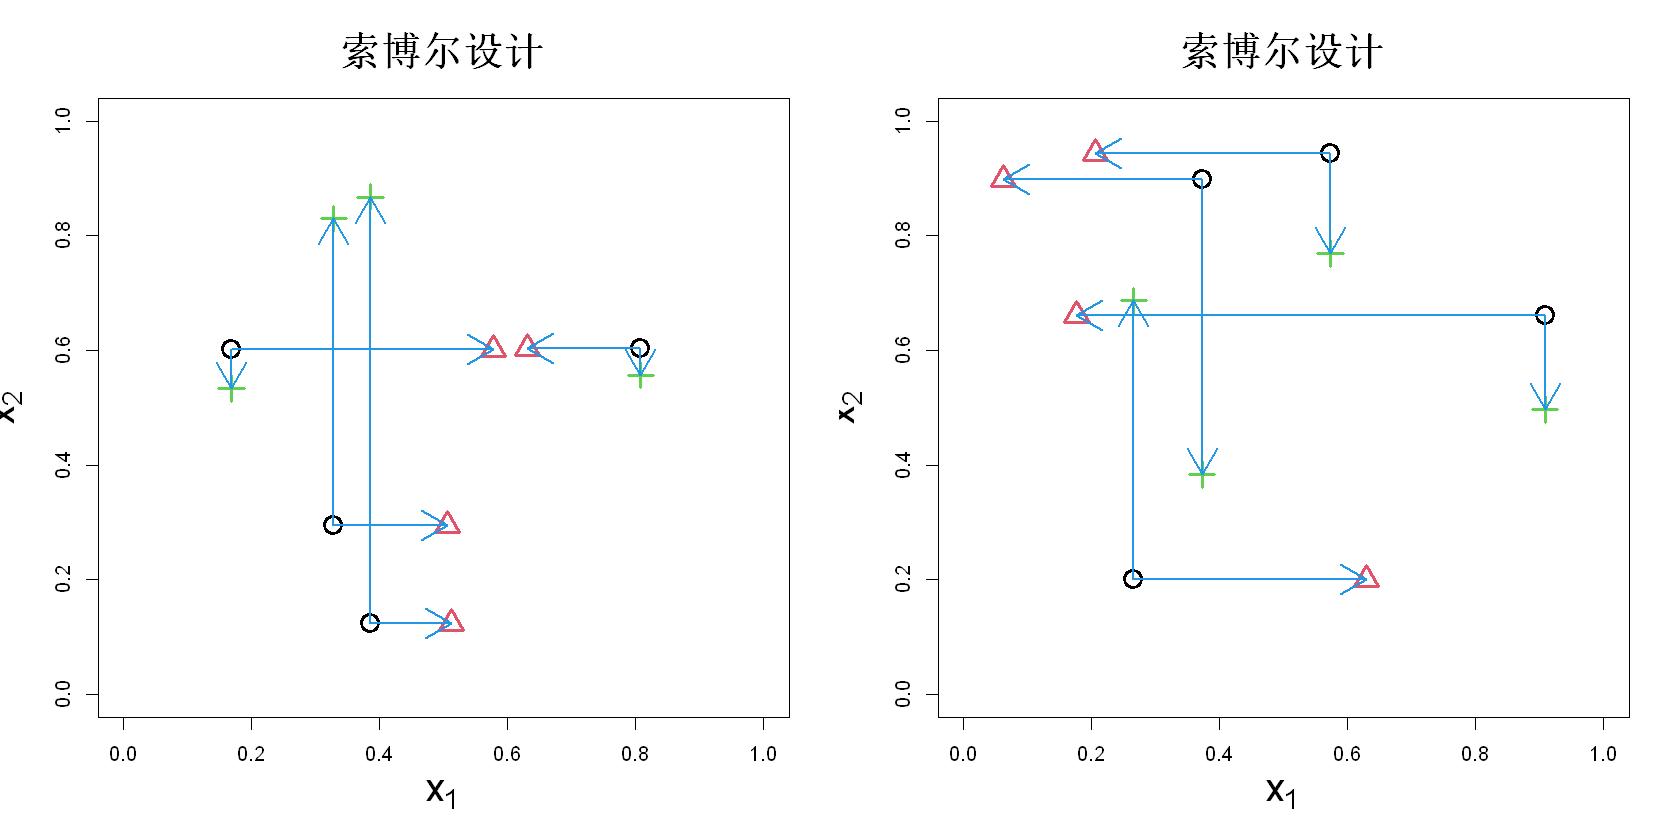

In [9]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/6.6-plot.RData")){
set.seed(3)
A1=matrix(runif(4*2),nrow=4,ncol=2) # 4x2
B1=matrix(runif(4*2),nrow=4,ncol=2) # 4x2
C11=cbind(B1[,1],A1[,2]) # 4x2
C12=cbind(A1[,1],B1[,2]) # 4x2
D1=rbind(A1,C11,C12) # 12x2
set.seed(1)
A2=matrix(runif(4*2),nrow=4,ncol=2) # 4x2
B2=matrix(runif(4*2),nrow=4,ncol=2) # 4x2
C21=cbind(B2[,1],A2[,2]) # 4x2
C22=cbind(A2[,1],B2[,2]) # 4x2
D2=rbind(A2,C21,C22) # 12x2
save(D1,D2,A1,C11,C12,A2,C21,C22,file="data/6.6-plot.RData")
}

load("data/6.6-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
plot(A1,xlab=expression(x[1]),ylab=expression(x[2]),xlim=c(0,1),ylim=c(0,1),lwd=3,cex=2,main="索博尔设计",cex.main=2, cex.lab=2)
points(C11,col=2,pch=2,lwd=3,cex=2)
points(C12,col=3,pch=3,lwd=3,cex=2)
for(i in 1:4){
  arrows(D1[i,1],D1[i,2],D1[i+4,1],D1[i+4,2],col=4,lwd=2)
  arrows(D1[i,1],D1[i,2],D1[i+8,1],D1[i+8,2],col=4,lwd=2)
}
plot(A2,xlab=expression(x[1]),ylab=expression(x[2]),xlim=c(0,1),ylim=c(0,1),lwd=3,cex=2,main="索博尔设计",cex.main=2, cex.lab=2)
points(C21,col=2,pch=2,lwd=3,cex=2)
points(C22,col=3,pch=3,lwd=3,cex=2)
for(i in 1:4){
  arrows(D2[i,1],D2[i,2],D2[i+4,1],D2[i+4,2],col=4,lwd=2)
  arrows(D2[i,1],D2[i,2],D2[i+8,1],D2[i+8,2],col=4,lwd=2)
}

> **图 6.7**：最大单因素逐次设计（左侧）以及加入投影后的最大单因素逐次设计（右侧）。单因素逐次设计结构用箭头标出

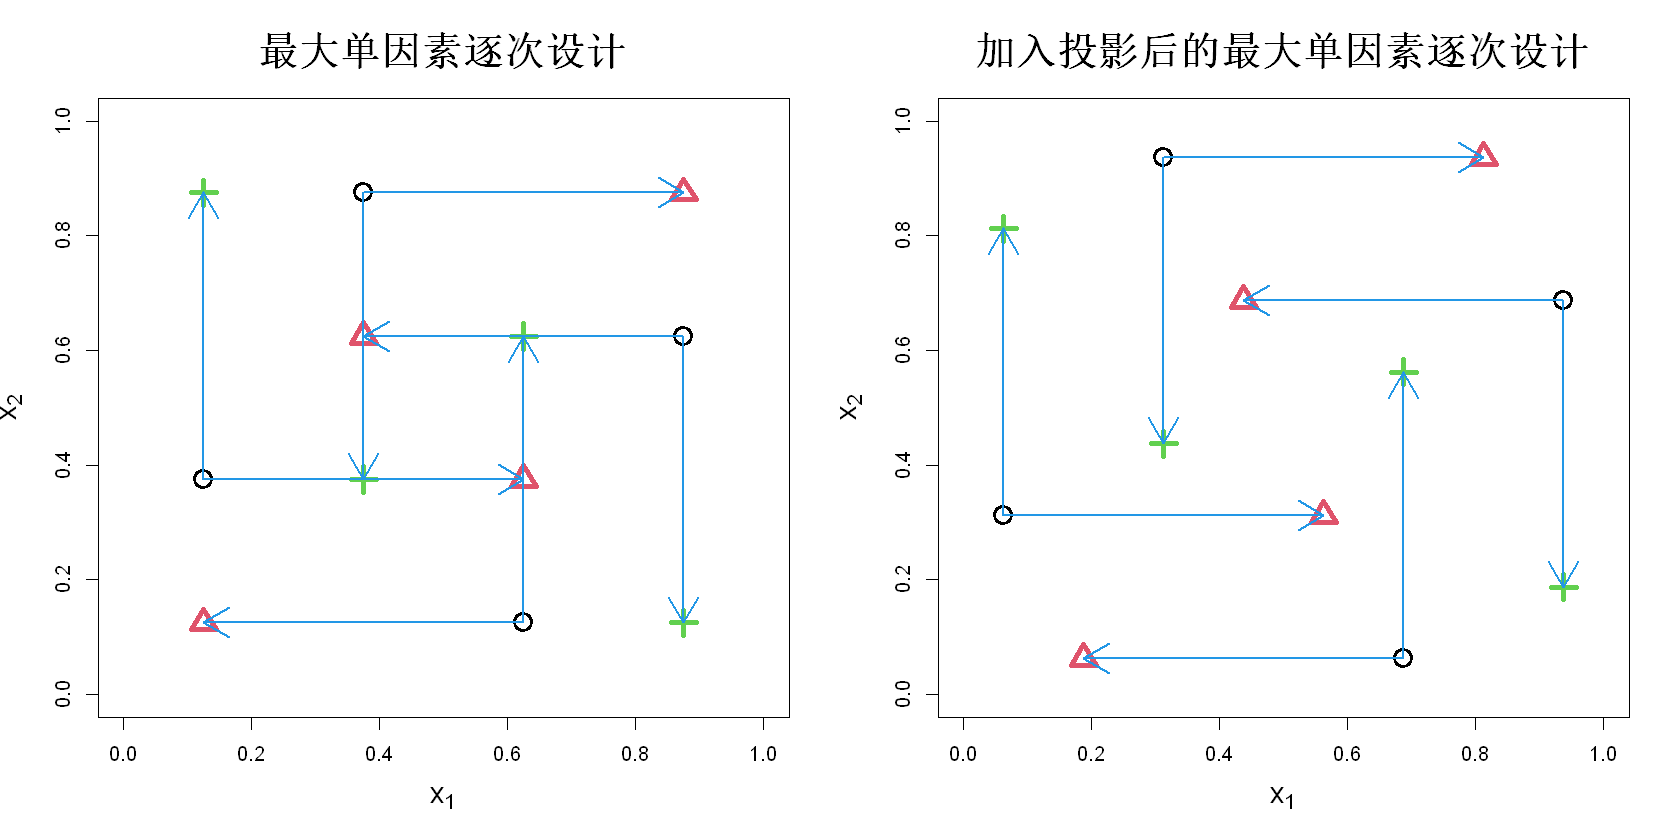

In [10]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/6.7-plot.RData")){
  library(MOFAT)
  p=2;l=4;s=1
  set.seed(s)
  D1=mofat(p,l,method="uniform") # 12x2
  A1=D1[1:4,] # 4x2
  C11=D1[(l+1):(2*l),] # 4x2
  C12=D1[(2*l+1):(3*l),] # 4x2
  set.seed(s)
  D2=mofat(p,l,method="projection") # 12x2
  A2=D2[1:4,] # 4x2
  C21=D2[(l+1):(2*l),] # 4x2
  C22=D2[(2*l+1):(3*l),] # 4x2
  save(D1,D2,A1,C11,C12,A2,C21,C22,file="data/6.7-plot.RData")
}

load("data/6.7-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
plot(A1,xlab=expression(x[1]),ylab=expression(x[2]),xlim=c(0,1),ylim=c(0,1),lwd=3,cex=2,main="最大单因素逐次设计",cex.main=2,cex.main=2, cex.lab=1.5)
points(C11,col=2,pch=2,lwd=4,cex=2)
points(C12,col=3,pch=3,lwd=4,cex=2)
for(i in 1:4){
  arrows(A1[i,1],A1[i,2],C11[i,1],C11[i,2],col=4,lty=1,lwd=2)
  arrows(A1[i,1],A1[i,2],C12[i,1],C12[i,2],col=4,lty=1,lwd=2)
}
plot(A2,xlab=expression(x[1]),ylab=expression(x[2]),xlim=c(0,1),ylim=c(0,1),lwd=3,cex=2,main="加入投影后的最大单因素逐次设计",cex.main=2, cex.lab=1.5)
points(C21,col=2,pch=2,lwd=4,cex=2)
points(C22,col=3,pch=3,lwd=4,cex=2)
for(i in 1:4){
  arrows(A2[i,1],A2[i,2],C21[i,1],C21[i,2],col=4,lty=1,lwd=2)
  arrows(A2[i,1],A2[i,2],C22[i,1],C22[i,2],col=4,lty=1,lwd=2)
}

> **图 6.8**：将最大单因素逐次设计应用于钻孔函数的实验结果。图中展示了经过 100 次重复实验得到的 $\mu^*$ 的箱线图

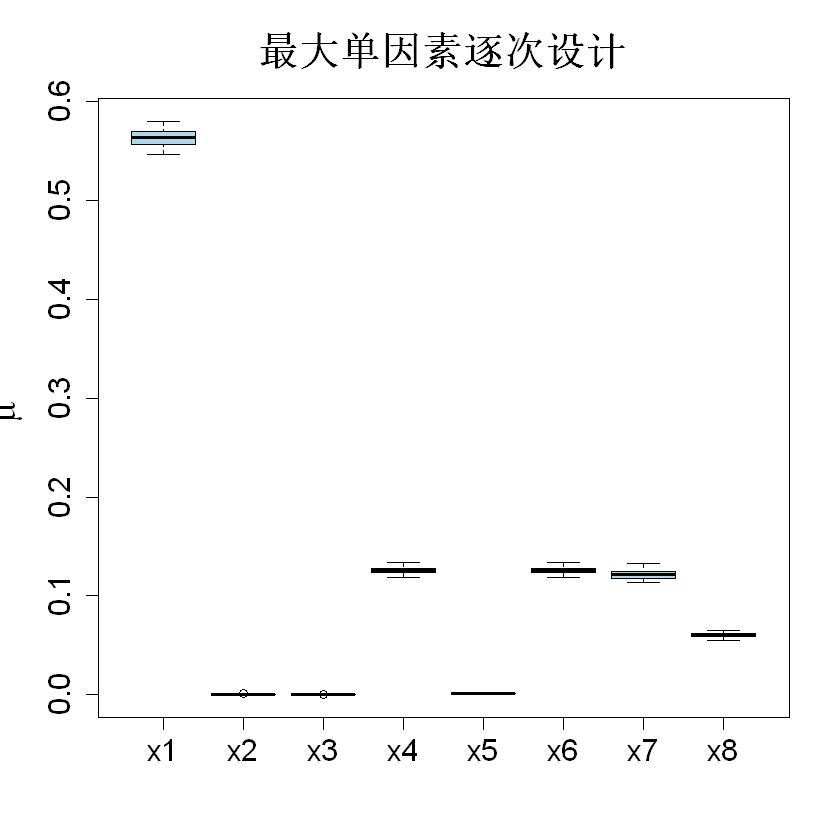

In [11]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/6.8-plot.RData")){
  library(MOFAT)
  f=function(x) {
    lower=c(0.05,100,63070,990,63.1,700,1120,9855)
    upper=c(0.15,50000,115600,1110,116,820,1680,12045)
    x=lower+x*(upper-lower)
    val=2*pi*x[3]*(x[4]-x[6])/(log(x[2]/x[1])*(1+2*x[7]*x[3]/(log(x[2]/x[1])*x[1]^2*x[8])+x[3]/x[5]))
    return(val)
  }
  p=8;m=4
  mustar=matrix(0,nrow=100,ncol=p)
  for(i in 1:100){
    d=mofat(p=8,l=m)
    y=apply(d,1,f)
    mustar[i,]=measure(d,y)$mustar
    mustar[i,]=mustar[i,]/sum(mustar[i,])
  }
  colnames(mustar)=paste("x",sep="",1:p)
  save(mustar,file="data/6.8-plot.RData")
}

options(repr.plot.width=7,repr.plot.height=7)
load("data/6.8-plot.RData")
boxplot(mustar, main="最大单因素逐次设计",cex.main=2,cex.axis=1.5,col="lightblue",ylab = expression(mu^"*"),cex.lab=1.75)